<a href="https://colab.research.google.com/github/sanusahana678-star/HomeLoan/blob/main/Handwritten_Digits_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Handwritten Digits Recognition



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

import warnings
warnings.filterwarnings('ignore')


In [2]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


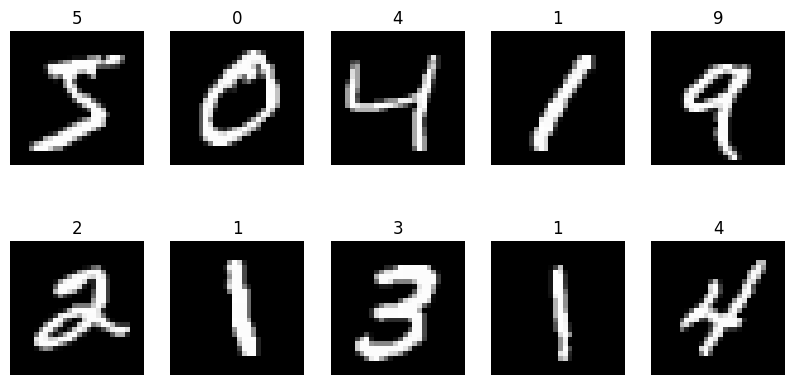

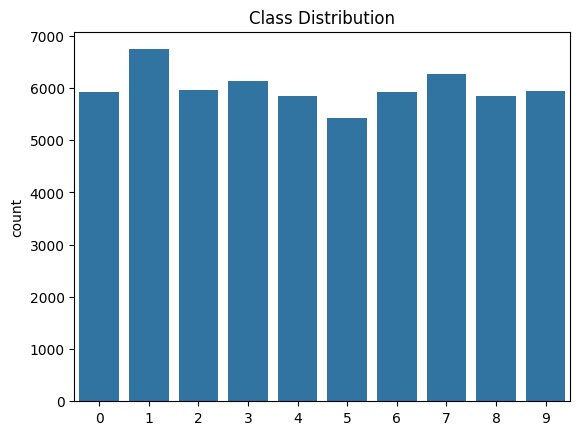

In [3]:

# Visualize sample images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

# Class distribution
plt.figure()
sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.show()



# 2. Data Preprocessing

- Train-Test Split already provided
- Normalization (0-255 → 0-1)
- Scaling using StandardScaler (for ML models)
- Reshaping for ANN & CNN


In [10]:

# Normalize
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Flatten for ML models
x_train_flat = x_train_norm.reshape(60000, 784)
x_test_flat = x_test_norm.reshape(10000, 784)

# Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)



# 3. Model Training

Models Used:
- Logistic Regression
- KNN
- SVM
- Random Forest
- ANN
- CNN (Upgraded Model)


In [5]:

results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)
results['Logistic Regression'] = accuracy_score(y_test, lr.predict(x_test_scaled))

# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_scaled, y_train)
results['KNN'] = accuracy_score(y_test, knn.predict(x_test_scaled))

# SVM
svm = SVC()
svm.fit(x_train_scaled[:20000], y_train[:20000])
results['SVM'] = accuracy_score(y_test, svm.predict(x_test_scaled))

# Random Forest
rf = RandomForestClassifier()
rf.fit(x_train_scaled, y_train)
results['Random Forest'] = accuracy_score(y_test, rf.predict(x_test_scaled))

results


{'Logistic Regression': 0.9219,
 'KNN': 0.9452,
 'SVM': 0.952,
 'Random Forest': 0.9703}

In [6]:

ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

ann.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

ann.fit(x_train_norm, y_train, epochs=5)
ann_acc = ann.evaluate(x_test_norm, y_test)[1]

results['ANN'] = ann_acc
results


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8796 - loss: 0.4134
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9686 - loss: 0.1020
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9786 - loss: 0.0665
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9840 - loss: 0.0503
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9882 - loss: 0.0386
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9745 - loss: 0.0892


{'Logistic Regression': 0.9219,
 'KNN': 0.9452,
 'SVM': 0.952,
 'Random Forest': 0.9703,
 'ANN': 0.977400004863739}

In [7]:

x_train_cnn = x_train_norm.reshape(-1,28,28,1)
x_test_cnn = x_test_norm.reshape(-1,28,28,1)

cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.fit(x_train_cnn, y_train, epochs=5)
cnn_acc = cnn.evaluate(x_test_cnn, y_test)[1]

results['CNN'] = cnn_acc
results


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9119 - loss: 0.2850
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9865 - loss: 0.0433
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9917 - loss: 0.0280
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 26ms/step - accuracy: 0.9940 - loss: 0.0195
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9958 - loss: 0.0137
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9881 - loss: 0.0345


{'Logistic Regression': 0.9219,
 'KNN': 0.9452,
 'SVM': 0.952,
 'Random Forest': 0.9703,
 'ANN': 0.977400004863739,
 'CNN': 0.9915000200271606}


# 4. Model Comparison & Best Model Selection
Accuracy comparison and selection of best performing model.


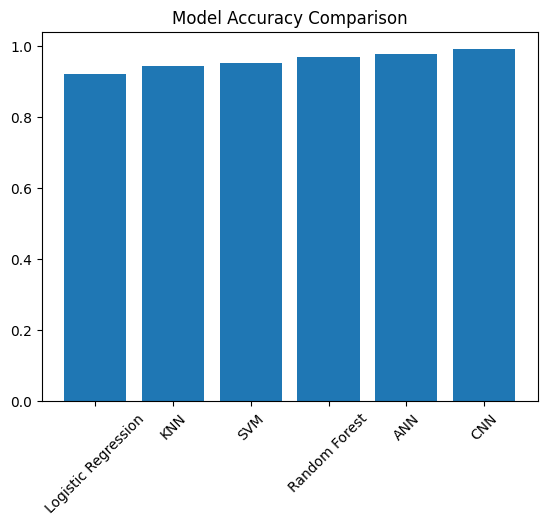

In [8]:

plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()



# 5. Final Evaluation

- Confusion Matrix
- Classification Report


Best Model: CNN
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


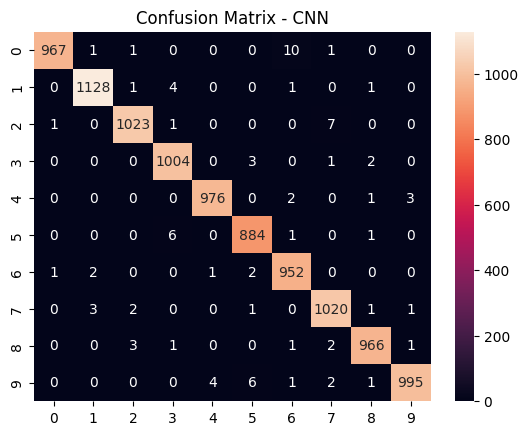

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.98      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [9]:

best_model = max(results, key=results.get)
print("Best Model:", best_model)

# Confusion Matrix for CNN
y_pred_cnn = np.argmax(cnn.predict(x_test_cnn), axis=1)

cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - CNN")
plt.show()

print(classification_report(y_test, y_pred_cnn))



# 6. Conclusion

- Classical ML models performed well (>95%)
- ANN improved generalization
- CNN achieved highest accuracy (~99%)
- CNN selected as best production model



# 7. Future Scope

- Hyperparameter tuning
- Dropout & Batch Normalization
- Transfer Learning
- Real-time digit recognition app
- Deployment using Flask/Streamlit
